<a href="https://colab.research.google.com/github/NgocAnhNguyen-0601/-Crypto-Currency-Bitcoin-Price-Prediction-/blob/main/crypto_currency_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [2]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)
stock = 'BTC-USD'
stock_data = yf.download(stock, start = start, end = end)


/tmp/ipykernel_3547/1837361621.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start = start, end = end)
[*********************100%***********************]  1 of 1 completed


In [3]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [4]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-05-27,74344.703125,76014.296875,74136.500000,75825.304688,33802172927
2026-05-28,73536.554688,74460.125000,72493.414062,74339.570312,40148145327
2026-05-29,73372.523438,74218.562500,72435.625000,73537.031250,34457929250
2026-05-30,73754.835938,74020.757812,73125.234375,73370.851562,19563589191
2026-05-31,73833.968750,74150.984375,73654.382812,73754.984375,17488840704


In [5]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,4275.000000,4275.000000,4275.000000,4275.000000,4.275000e+03
mean,28593.568512,29142.631914,27977.470058,28577.411303,2.226383e+10
std,32436.959192,32977.945358,31847.133573,32433.076629,2.292493e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,3452.954834,3498.564453,3381.571899,3432.903687,1.666155e+09
50%,11523.579102,11806.056641,11249.605469,11508.713867,1.800070e+10
75%,46352.582031,47331.126953,44771.396484,46298.623047,3.440956e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [6]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4275 entries, 2014-09-17 to 2026-05-31
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4275 non-null   float64
 1   (High, BTC-USD)    4275 non-null   float64
 2   (Low, BTC-USD)     4275 non-null   float64
 3   (Open, BTC-USD)    4275 non-null   float64
 4   (Volume, BTC-USD)  4275 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 200.4 KB


In [7]:
# Close Data Price
stock_data.columns
closing_price = stock_data[['Close']]
closing_price['Close']

Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2026-05-27,74344.703125
2026-05-28,73536.554688
2026-05-29,73372.523438


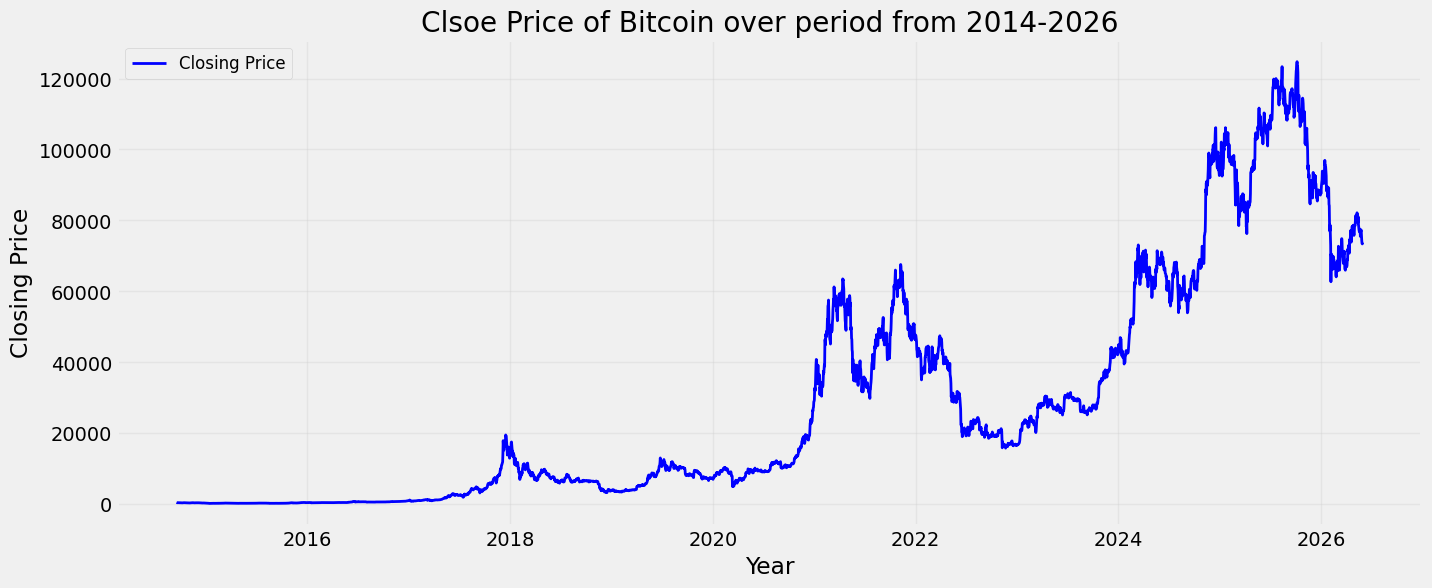

In [8]:
# Plot the closing price with trend:
plt.figure(figsize = (15,6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Closing Price', color = 'Blue', linewidth = 2)
plt.title("Clsoe Price of Bitcoin over period from 2014-2026")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [9]:
# Moving Average:
temp_data = [10,20,30,40,50,60,70,80,90,100]
# Moving avergae for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[0:5])/5)

30.0


In [10]:
df1 = pd.DataFrame(temp_data)

In [11]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [12]:
for i in range (2014, 2026):
  print(i, list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365
2024 366
2025 365


In [13]:
closing_price['MA_365'] = closing_price["Close"].rolling(window = 365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()

/tmp/ipykernel_3547/3538707382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price["Close"].rolling(window = 365).mean()
/tmp/ipykernel_3547/3538707382.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()


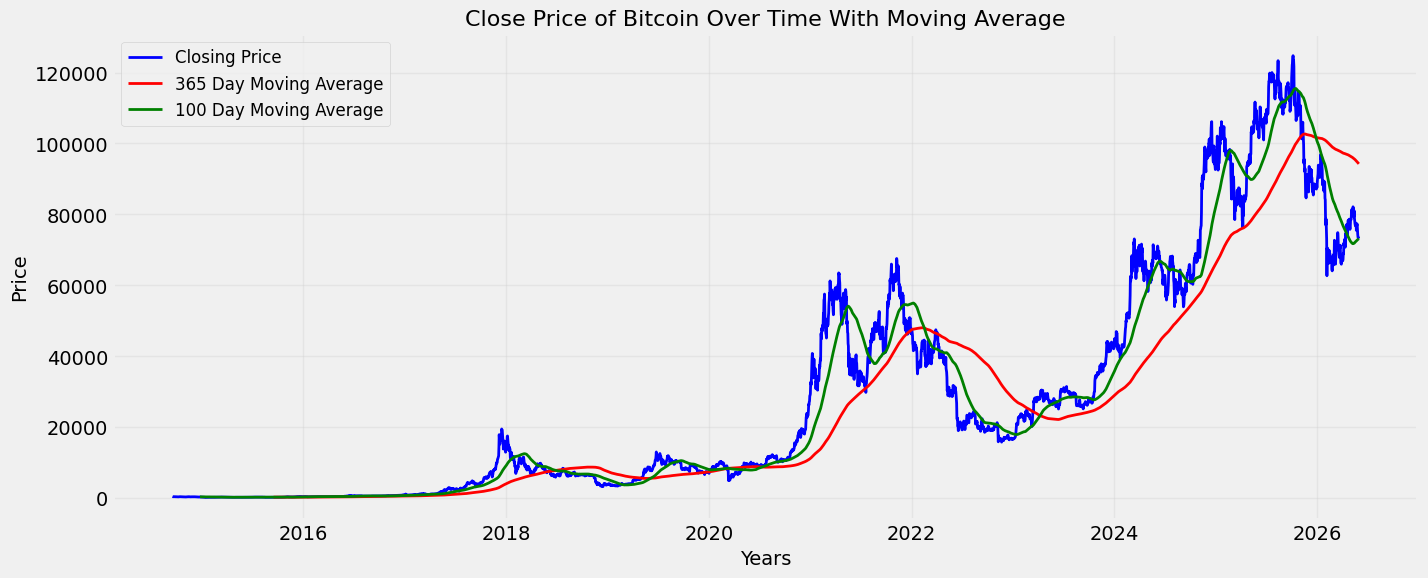

In [14]:
# PLot closing price with enhancement:
plt.figure(figsize = (15,6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Closing Price', color = 'Blue', linewidth = 2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Day Moving Average', color = 'Red', linewidth = 2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Day Moving Average', color = 'Green', linewidth = 2)

plt.title("Close Price of Bitcoin Over Time With Moving Average", fontsize = 16 )
plt.xlabel("Years", fontsize = 14)
plt.ylabel("Price", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()


LSTM - Long Short Term Memory

In [15]:
# Scale the data:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [16]:
scaled_data

array([[0.00224148],
       [0.00197743],
       [0.00173947],
       ...,
       [0.58755574],
       [0.59062469],
       [0.59125991]])

In [17]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [18]:
# Prepare Data for LSTM
x_data = []
y_data = []
base_days = 100
for i in range(base_days, len(scaled_data)):
  x_data.append(scaled_data[i-base_days:i])
  y_data.append(scaled_data[i])
x_data= np.array(x_data)
y_data=np.array(y_data)

In [19]:
# Splitting into train and test data:
train_size = int(len(x_data) * 0.9)
x_train, y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [20]:
model = Sequential([
    LSTM(128, return_sequences = True, input_shape = (x_train.shape[1], 1)),
    LSTM(64, return_sequences = False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer = 'adam', loss = "mean_squared_error")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.fit(x_train, y_train, batch_size = 5, epochs = 10)

Epoch 1/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 9.6103e-04
Epoch 2/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 3.3889e-04
Epoch 3/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 2.1954e-04
Epoch 4/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.8528e-04
Epoch 5/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 2.0969e-04
Epoch 6/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.6859e-04
Epoch 7/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.5903e-04
Epoch 8/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 1.3029e-04
Epoch 9/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.3985e-04
Epoch 10/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 1.3683e-04


In [22]:
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [23]:
inv_predictions

array([[ 76047.164],
       [ 82418.086],
       [ 79350.41 ],
       [ 83086.93 ],
       [ 84884.48 ],
       [ 83114.336],
       [ 83984.76 ],
       [ 83101.1  ],
       [ 83508.61 ],
       [ 84396.805],
       [ 83918.1  ],
       [ 84541.55 ],
       [ 84637.64 ],
       [ 87010.695],
       [ 92986.086],
       [ 92872.74 ],
       [ 92983.55 ],
       [ 93759.266],
       [ 93656.19 ],
       [ 92757.4  ],
       [ 94119.086],
       [ 93358.96 ],
       [ 93325.32 ],
       [ 95729.03 ],
       [ 96015.81 ],
       [ 94887.17 ],
       [ 93316.19 ],
       [ 93907.625],
       [ 96066.58 ],
       [ 96164.04 ],
       [102633.46 ],
       [101804.945],
       [103552.25 ],
       [102761.086],
       [101451.18 ],
       [103053.125],
       [102308.734],
       [102590.805],
       [102319.914],
       [102037.03 ],
       [105537.11 ],
       [104327.07 ],
       [105627.74 ],
       [108605.05 ],
       [110428.04 ],
       [105454.56 ],
       [106473.48 ],
       [10783

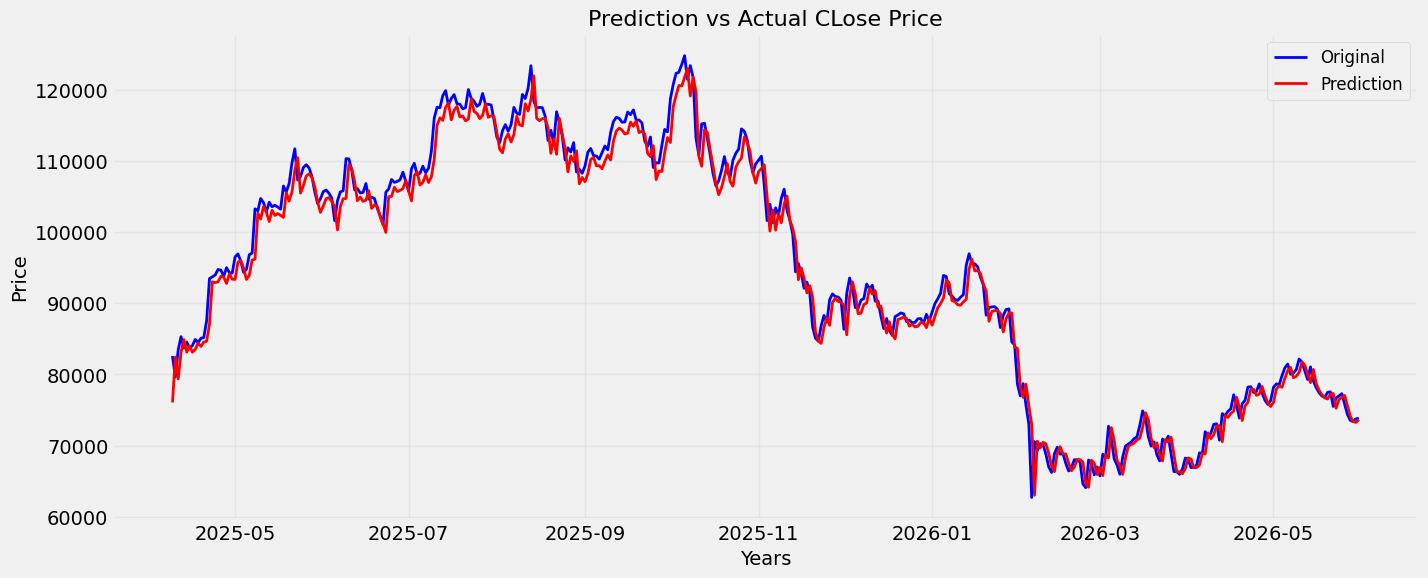

In [24]:
plotting_data = pd.DataFrame(
    {
        "Original": inv_y_test.flatten(),
        "Prediction": inv_predictions.flatten(),
    }, index = closing_price.index[train_size+base_days:]
)

plt.figure(figsize = (15,6))
plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original', color = 'Blue', linewidth = 2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction', color = 'Red', linewidth = 2)

plt.title("Prediction vs Actual CLose Price", fontsize = 16 )
plt.xlabel("Years", fontsize = 14)
plt.ylabel("Price", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()


In [26]:
# Predict Future Days
last_100 = scaled_data[-100:].reshape(1,-1,1)
future_predictions = []
for _ in range(10):
  next_days = model.predict(last_100)
  future_predictions.append(scaler.inverse_transform(next_days))
  last_100 = np.append(last_100[:, 1:, :], next_days.reshape(1,1,-1), axis = 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [27]:
last_100

array([[[0.54678594],
        [0.58224209],
        [0.56723537],
        [0.54552439],
        [0.53858959],
        [0.52813149],
        [0.54765878],
        [0.55989676],
        [0.56212805],
        [0.56444456],
        [0.56825597],
        [0.57023358],
        [0.58287894],
        [0.59950492],
        [0.5919704 ],
        [0.57048205],
        [0.55978331],
        [0.56467835],
        [0.55014036],
        [0.54318618],
        [0.56782726],
        [0.56464041],
        [0.57099824],
        [0.55078336],
        [0.53109031],
        [0.53094036],
        [0.52801221],
        [0.53392452],
        [0.5463016 ],
        [0.54505931],
        [0.53550691],
        [0.53584832],
        [0.53873346],
        [0.55231075],
        [0.55133085],
        [0.57606205],
        [0.56950096],
        [0.57467432],
        [0.58439717],
        [0.58500104],
        [0.56653122],
        [0.59648307],
        [0.59405054],
        [0.59905533],
        [0.60184125],
        [0

In [28]:
future_predictions

[array([[73721.09]], dtype=float32),
 array([[73588.24]], dtype=float32),
 array([[73440.18]], dtype=float32),
 array([[73286.19]], dtype=float32),
 array([[73131.77]], dtype=float32),
 array([[72979.69]], dtype=float32),
 array([[72831.01]], dtype=float32),
 array([[72685.914]], dtype=float32),
 array([[72544.195]], dtype=float32),
 array([[72405.555]], dtype=float32)]

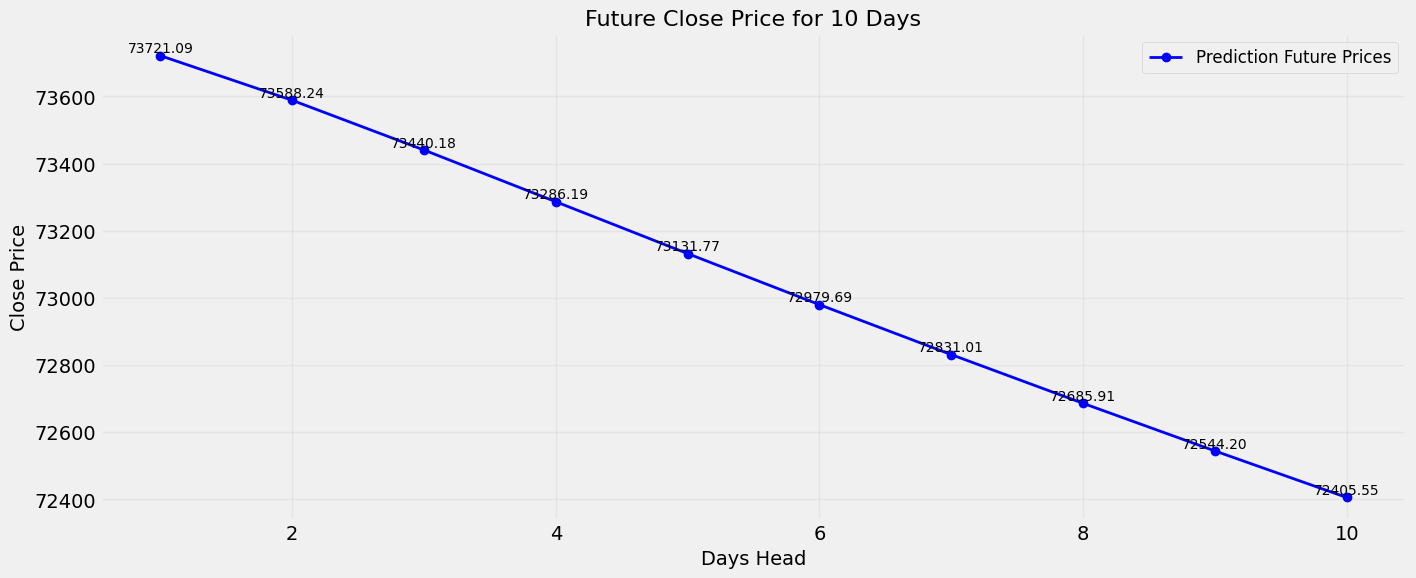

In [32]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize = (15,6))
plt.plot(range(1,11), future_predictions, marker ="o", label = 'Prediction Future Prices', color = 'Blue', linewidth = 2)
for i, val in enumerate(future_predictions):
  plt.text(i+1, val,  f'{val:.2f}', fontsize = 10, ha='center', va='bottom', color='black')

plt.title("Future Close Price for 10 Days", fontsize = 16 )
plt.xlabel("Days Head", fontsize = 14)
plt.ylabel("Close Price", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [33]:
model.save("model.keras")